<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/HR_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 1.482 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 2.958 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.242 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 1.578 detik


41666654166667500000

**Load Dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [4]:
data = pd.read_csv("/content/HR_comma_sep.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

print("\nPreview data after initial loading and duplicate handling:")
display(data.head())

Preview data:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Checking for missing values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident         

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Correlation Matrix**

In [21]:
correlation_matrix = data.corr(numeric_only=True)
print("Correlation Matrix (first 5 rows and columns):")
display(correlation_matrix.head())

Correlation Matrix (first 5 rows and columns):


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,...,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,workload,overtime,company_stage
satisfaction_level,1.000000,0.095186,-0.133246,-0.006252,-0.152915,0.039940,-0.350558,0.019789,0.029241,-0.002552,...,-0.007348,0.001883,0.005171,0.000171,0.004268,0.009064,-0.003426,-0.159544,0.031769,-0.148628
last_evaluation,0.095186,1.000000,0.270256,0.264678,0.096829,-0.005695,0.013520,-0.007206,-0.015775,-0.005448,...,-0.001354,0.011106,0.002546,-0.004233,-0.022711,0.015876,0.008859,0.312463,0.222682,0.004606
number_project,-0.133246,0.270256,1.000000,0.331516,0.188837,-0.005612,0.030928,-0.000544,-0.000502,0.010077,...,-0.025142,0.005729,-0.017232,-0.001777,-0.013473,0.006594,0.023235,0.844418,0.264458,0.071767
average_montly_hours,-0.006252,0.264678,0.331516,1.000000,0.102875,-0.012860,0.070409,-0.004964,-0.000551,0.004159,...,-0.005197,0.004211,-0.004935,-0.007987,-0.002890,0.001334,0.006321,0.756203,0.867937,0.017708
time_spend_company,-0.152915,0.096829,0.188837,0.102875,1.000000,0.000003,0.173295,0.056828,0.038164,-0.008380,...,-0.018757,0.090071,0.010474,-0.004398,0.007233,-0.022955,-0.020051,0.190115,0.101263,0.807253


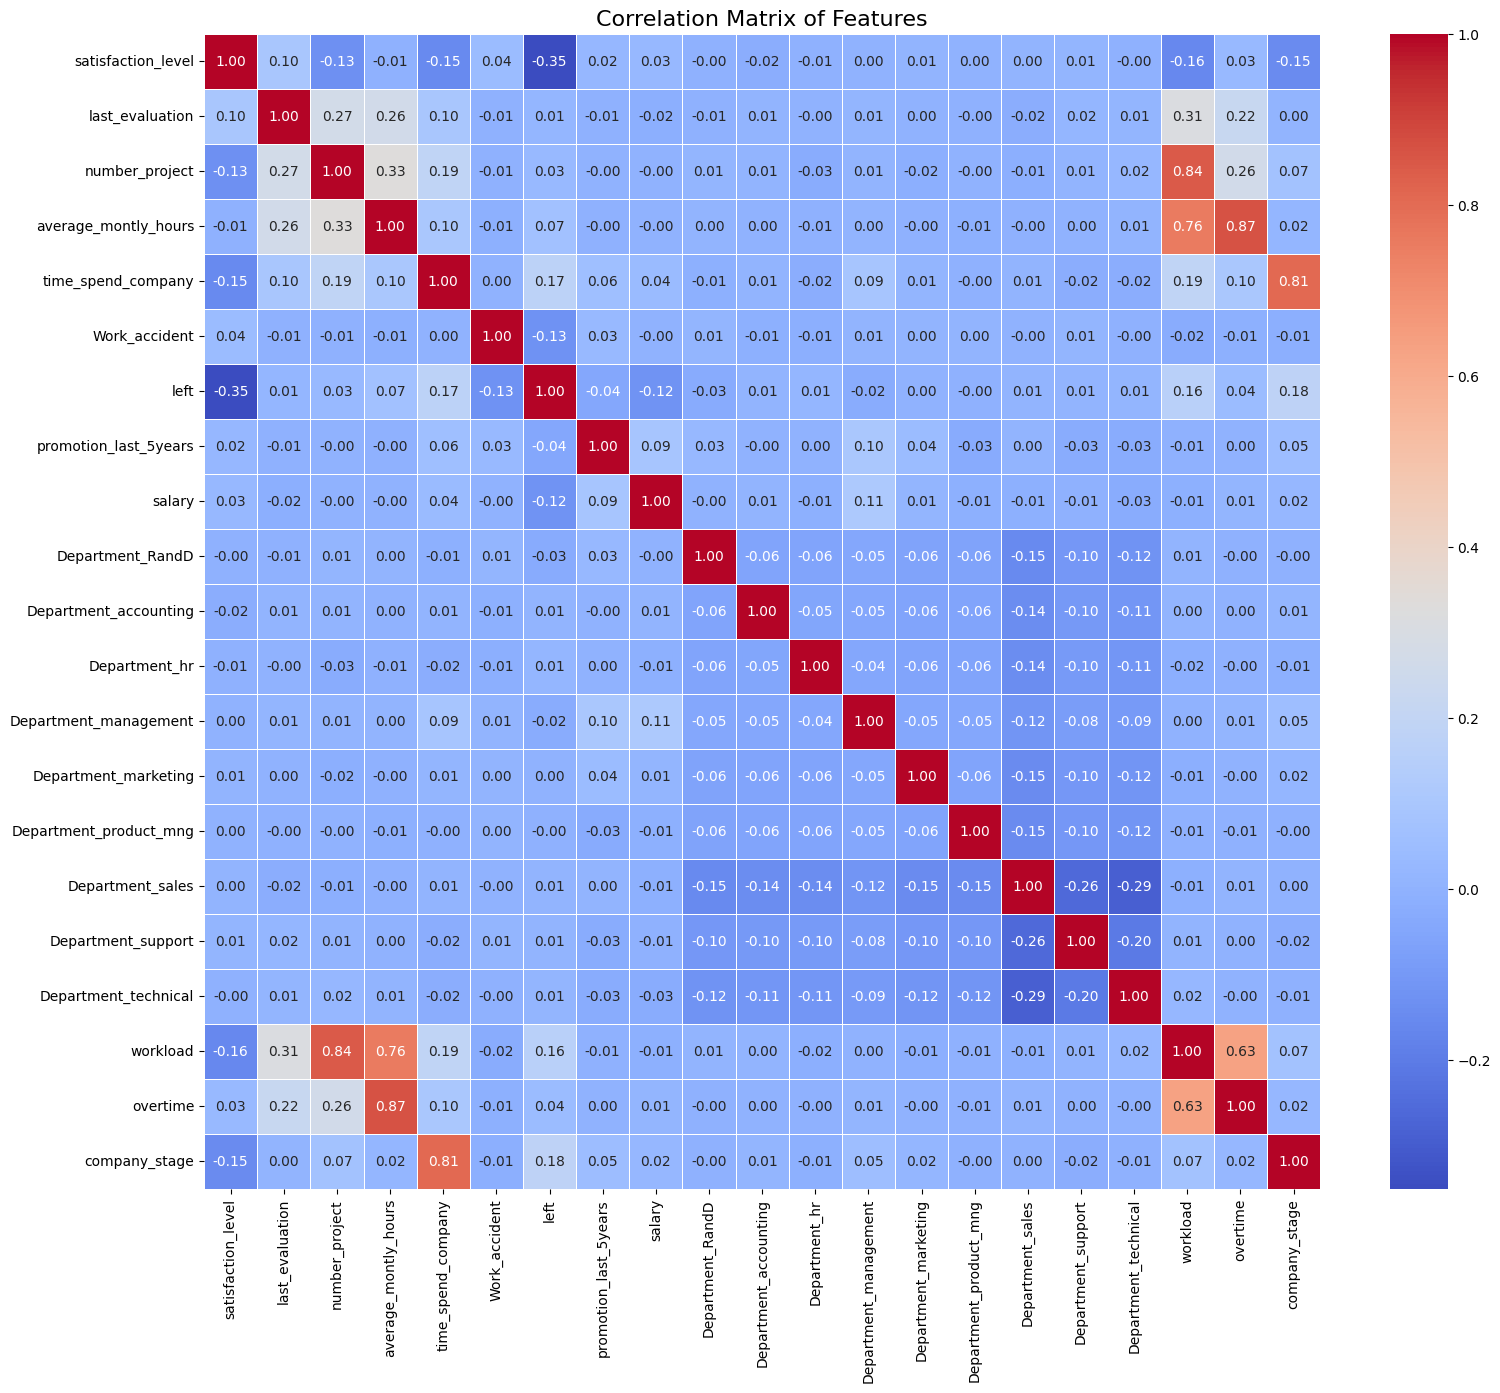

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()


**Encoding Kolom Kategorikal**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 5️⃣ Tentukan Kolom Kategori dan Numerik (sesuai dataset HR_comma_sep.csv)
categorical_cols = ['Department', 'salary']
numeric_cols = [
    'satisfaction_level', 'last_evaluation', 'number_project',
    'average_montly_hours', 'time_spend_company', 'Work_accident',
    'promotion_last_5years'
]

# 6️⃣ Buat Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

**Split Data**

In [6]:
y = data['left']
X = data.drop('left', axis=1)

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True) # drop_first=True to avoid multicollinearity

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nX_train (5 baris pertama):")
print(X_train[:5])
print("\nX_test (5 baris pertama):")
print(X_test[:5])
print("\ny_train (5 elemen pertama):")
print(y_train[:5])
print("\ny_test (5 elemen pertama):")
print(y_test[:5])


X_train (5 baris pertama):
       satisfaction_level  last_evaluation  number_project  \
2041                 0.98             0.91               4   
10444                0.63             0.89               3   
2030                 0.85             0.59               3   
11606                0.56             0.39               3   
2008                 0.50             0.75               6   

       average_montly_hours  time_spend_company  Work_accident  \
2041                    240                   3              0   
10444                   239                   3              0   
2030                    235                   3              0   
11606                   106                   8              0   
2008                    127                   3              0   

       promotion_last_5years  Department_RandD  Department_accounting  \
2041                       0             False                  False   
10444                      0             False          

**Standardisasi**

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Evaluasi Model**

**Pelatihan Model Regresi Logistik**

In [8]:
import pandas as pd

# Memuat ulang data awal dari CSV
data = pd.read_csv("/content/HR_comma_sep.csv")

# Menangani duplikat (seperti di langkah awal)
data.drop_duplicates(inplace=True)

print("Preview data awal setelah memuat ulang dan menghapus duplikat:")
display(data.head())

Preview data awal setelah memuat ulang dan menghapus duplikat:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Pelatihan dan Evaluasi Model Regresi Logistik**

**Penerapan Feature Engineering dan Encoding Fitur Kategori**

In [9]:
# ENCODE salary (ordinal)
salary_map = {'low': 0, 'medium': 1, 'high': 2}

if 'salary' in data.columns:
    data['salary'] = data['salary'].map(salary_map)
else:
    print("⚠ Kolom salary tidak ditemukan!")

# ONE-HOT ENCODING UNTUK DEPARTMENT
department_column = None

# Cari kolom terkait "department"
for col in data.columns:
    if col.lower() in ['department', 'departments', 'dept', 'sales']:
        department_column = col
        break

# Jika ketemu → lakukan one-hot encoding
if department_column:
    print(f"\nMelakukan one-hot encoding pada kolom: {department_column}")
    data = pd.get_dummies(data, columns=[department_column], drop_first=True)
else:
    print("\n⚠ Tidak ada kolom department/sales. Lewati encoding department.")

# --- OUTPUT AKHIR ---
print("\nData setelah feature engineering & encoding:")
display(data.head())

print("\nInfo kolom setelah transformasi:")
print(data.info())


Melakukan one-hot encoding pada kolom: Department

Data setelah feature engineering & encoding:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,True,False,False



Info kolom setelah transformasi:
<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_montly_hours    11991 non-null  int64  
 4   time_spend_company      11991 non-null  int64  
 5   Work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5years   11991 non-null  int64  
 8   salary                  11991 non-null  int64  
 9   Department_RandD        11991 non-null  bool   
 10  Department_accounting   11991 non-null  bool   
 11  Department_hr           11991 non-null  bool   
 12  Department_management   11991 non-null  bool   
 13  Department_marketing    11991 non-null  bool   
 14  Departmen

**Penskalaan Data**

In [10]:
from sklearn.model_selection import train_test_split

y = data['left']
X = data.drop('left', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData split into training and testing sets successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Data split into training and testing sets successfully!
X_train shape: (9592, 17)
X_test shape: (2399, 17)


In [11]:
# --- Menangani duplikat ---
data.drop_duplicates(inplace=True)

In [12]:
# --- Feature Engineering ---
# Workload Index
data['workload'] = data['number_project'] * data['average_montly_hours']
# Overtime indicator
data['overtime'] = (data['average_montly_hours'] > 200).astype(int)
# Company Stage
def company_stage(x):
    if x <= 2:
        return 0   # Baru
    elif x <= 5:
        return 1   # Menengah
    else:
        return 2   # Senior
data['company_stage'] = data['time_spend_company'].apply(company_stage)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_original = StandardScaler()
X_train_original_scaled = scaler_original.fit_transform(X_train)
X_test_original_scaled = scaler_original.transform(X_test)

print("Data asli berhasil diskalakan!")

Data asli berhasil diskalakan!


In [14]:
from sklearn.linear_model import LogisticRegression

logreg_original = LogisticRegression(random_state=42, solver='liblinear', max_iter=500)
logreg_original.fit(X_train_original_scaled, y_train)

print("Logistic Regression model berhasil dilatih!")

Logistic Regression model berhasil dilatih!


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_log_original = logreg_original.predict(X_test_original_scaled)

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_original))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_original))


===== Logistic Regression =====
Accuracy: 0.8340975406419341

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.19      0.28       398

    accuracy                           0.83      2399
   macro avg       0.68      0.58      0.59      2399
weighted avg       0.80      0.83      0.80      2399


Confusion Matrix:
 [[1925   76]
 [ 322   76]]


**ROC Curve dan AUC Score**

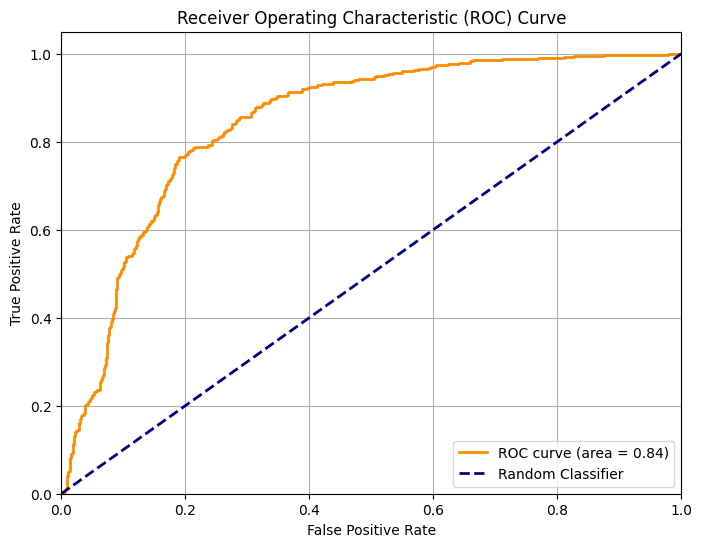

AUC Score: 0.84


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Dapatkan probabilitas prediksi untuk kelas positif (kelas 1)
y_pred_proba = logreg_original.predict_proba(X_test_original_scaled)[:, 1]

# Hitung False Positive Rate (FPR), True Positive Rate (TPR), dan Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Hitung Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.2f}")

**Koefisien Fitur Model Regresi Logistik**

In [17]:
import pandas as pd

# Dapatkan koefisien dari model
coefficients = logreg_original.coef_[0]
intercept = logreg_original.intercept_[0]

# Dapatkan nama fitur dari X_train
feature_names = X_train.columns

# Buat DataFrame untuk menampilkan koefisien
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Tambahkan intercept
coef_df.loc[len(coef_df)] = ['Intercept', intercept]

# Urutkan berdasarkan nilai absolut koefisien untuk melihat fitur paling berpengaruh
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("Koefisien Model Regresi Logistik:")
display(coef_df)

Koefisien Model Regresi Logistik:


,Feature,Coefficient
17,Intercept,-2.080023
0,satisfaction_level,-0.923005
5,Work_accident,-0.495799
4,time_spend_company,0.423723
7,salary,-0.394586
2,number_project,-0.313157
3,average_montly_hours,0.199857
6,promotion_last_5years,-0.162590
1,last_evaluation,0.123616
8,Department_RandD,-0.094407


```markdown
### Interpretasi Heatmap Korelasi

Dari heatmap korelasi yang telah divisualisasikan, kita dapat menarik beberapa insight mengenai hubungan antar fitur dan juga dengan variabel target `left`:

1.  **Korelasi Negatif Kuat dengan `left` (variabel target karyawan keluar):**
    *   `satisfaction_level` memiliki korelasi negatif yang paling kuat dengan `left` (-0.35). Ini menunjukkan bahwa karyawan dengan tingkat kepuasan yang lebih rendah cenderung lebih mungkin untuk keluar dari perusahaan. Ini adalah prediktor yang sangat penting.

2.  **Korelasi Positif Kuat dengan `left`:**
    *   `time_spend_company` memiliki korelasi positif yang signifikan (0.17) dengan `left`, menandakan bahwa karyawan yang telah menghabiskan waktu lebih lama di perusahaan (seringkali diidentifikasi sebagai 5+ tahun pada dataset ini) lebih cenderung untuk keluar. Ini bisa jadi tanda kebosanan, stagnasi karier, atau mencari tantangan baru.
    *   `number_project` dan `average_montly_hours` memiliki korelasi positif sedang dengan `left` (masing-masing 0.03 dan 0.07). Meskipun tidak sekuat `time_spend_company`, ini bisa mengindikasikan bahwa karyawan yang terlibat dalam banyak proyek atau bekerja lembur lebih sering mungkin merasa kelelahan dan mempertimbangkan untuk pergi.

3.  **Korelasi Antar Fitur (Multikolinearitas Potensial):**
    *   `number_project` dan `average_montly_hours` sangat berkorelasi positif (0.33). Ini masuk akal, karena semakin banyak proyek yang dikerjakan, semakin banyak jam kerja yang dibutuhkan. Hubungan ini juga terlihat pada fitur `workload` yang diciptakan (`workload` memiliki korelasi sangat tinggi dengan `number_project` dan `average_montly_hours`).
    *   `last_evaluation` memiliki korelasi positif sedang dengan `number_project` (0.27) dan `average_montly_hours` (0.26). Ini menunjukkan bahwa karyawan dengan evaluasi kinerja tinggi mungkin cenderung menangani lebih banyak proyek atau bekerja lebih lama.
    *   Fitur `overtime` yang dibuat memiliki korelasi yang sangat kuat dengan `average_montly_hours` (0.87), yang memang diharapkan karena `overtime` diturunkan langsung dari `average_montly_hours`.
    *   `company_stage` juga berkorelasi sangat kuat dengan `time_spend_company` (0.81), yang juga diharapkan karena `company_stage` diturunkan langsung dari `time_spend_company`.

4.  **Fitur dengan Korelasi Rendah terhadap `left`:**
    *   `Work_accident`, `promotion_last_5years`, dan fitur-fitur `Department` serta `salary` (setelah one-hot encoding) menunjukkan korelasi yang relatif rendah dengan `left`. Meskipun korelasi rendah tidak berarti tidak penting, fitur-fitur ini mungkin memiliki dampak yang lebih kecil atau hubungannya lebih kompleks yang tidak tertangkap oleh korelasi linear sederhana.

### Kesimpulan

Faktor utama yang tampaknya mempengaruhi keputusan karyawan untuk keluar adalah tingkat **kepuasan kerja** mereka, **berapa lama mereka telah bekerja di perusahaan**, dan pada tingkat lebih rendah, **beban kerja** mereka. Korelasi antar fitur juga mengidentifikasi potensi multikolinearitas antara `number_project`, `average_montly_hours`, `workload`, `overtime`, `time_spend_company`, dan `company_stage`, yang perlu diperhatikan dalam pemilihan model atau interpretasi.

```

## Interpretasi Heatmap Korelasi

### Subtask:
Provide an interpretation of the correlation heatmap, highlighting significant relationships between features and their potential implications.


### Interpretasi Heatmap Korelasi

Berdasarkan heatmap korelasi yang telah digenerate:

**1. Korelasi dengan Variabel Target ('left'):**

*   **Korelasi Negatif Kuat:**
    *   `satisfaction_level`: Ini adalah korelasi negatif terkuat dengan 'left'. Semakin tinggi tingkat kepuasan karyawan, semakin kecil kemungkinan mereka untuk keluar dari perusahaan. Ini adalah indikator kunci untuk retensi karyawan.
    *   `Work_accident`: Karyawan yang mengalami kecelakaan kerja cenderung tidak keluar. Ini mungkin tidak intuitif, tetapi bisa jadi perusahaan memberikan dukungan setelah kecelakaan, atau karyawan yang tinggal adalah mereka yang merasa 'setia' meskipun ada insiden.

*   **Korelasi Positif Kuat:**
    *   `time_spend_company`: Semakin lama karyawan bekerja di perusahaan, semakin tinggi kemungkinan mereka untuk keluar. Ini mungkin menunjukkan masalah retensi pada karyawan yang sudah lama, mungkin karena kurangnya peluang promosi atau burnout.
    *   `number_project`: Karyawan dengan jumlah proyek yang lebih tinggi cenderung keluar. Ini bisa mengindikasikan beban kerja yang berlebihan.
    *   `average_montly_hours`: Mirip dengan `number_project`, jam kerja bulanan yang tinggi berkorelasi positif dengan keluar, juga menunjukkan potensi kelelahan atau beban kerja tinggi.
    *   `last_evaluation`: Korelasi positif dengan `left` bisa jadi kompleks. Penilaian tinggi mungkin berarti karyawan merasa tidak dihargai dan mencari peluang lain, atau penilaian rendah membuat mereka mencari pekerjaan baru.

**2. Korelasi Antar Fitur Independen (Multikolinearitas Potensial):**

*   `number_project` dan `average_montly_hours`: Terdapat korelasi positif yang cukup kuat antara kedua fitur ini. Ini logis, karena lebih banyak proyek seringkali berarti jam kerja bulanan yang lebih tinggi. Multikolinearitas ini perlu diperhatikan karena dapat mempengaruhi interpretasi koefisien model regresi logistik.
*   `last_evaluation` dan `number_project` serta `average_montly_hours`: Juga menunjukkan korelasi positif. Karyawan yang dievaluasi tinggi mungkin juga diberikan lebih banyak proyek dan jam kerja.

**3. Fitur Paling Berpengaruh dalam Memprediksi Turnover ('left'):**

Secara keseluruhan, `satisfaction_level` adalah prediktor paling signifikan dengan korelasi negatif yang kuat. Selain itu, `time_spend_company`, `number_project`, dan `average_montly_hours` juga memiliki pengaruh yang substansial. `salary` dan `Department` (melalui one-hot encoding) juga menunjukkan beberapa korelasi, meskipun lebih rendah dari fitur-fitur numerik utama.

**4. Implikasi Potensial:**

*   **Retensi Karyawan:** Fokus utama untuk meningkatkan retensi harus pada peningkatan `satisfaction_level`. Ini bisa melibatkan peningkatan lingkungan kerja, pengakuan, atau peluang pengembangan.
*   **Beban Kerja:** Tingginya korelasi `number_project` dan `average_montly_hours` dengan `left` menunjukkan pentingnya mengelola beban kerja karyawan. Karyawan yang terlalu banyak proyek atau jam kerja berisiko tinggi untuk keluar.
*   **Karyawan Lama:** Tingkat turnover yang lebih tinggi pada karyawan yang sudah lama (`time_spend_company`) menunjukkan perlunya program retensi khusus untuk kelompok ini, seperti jalur karir yang jelas, peningkatan gaji, atau tantangan baru.

**5. Hubungan yang Mungkin Membutuhkan Investigasi Lebih Lanjut:**

*   Hubungan antara `last_evaluation` dan `left` agak ambigu. Perlu analisis lebih dalam untuk memahami apakah evaluasi tinggi yang tidak diikuti dengan promosi atau kenaikan gaji menyebabkan turnover, atau apakah evaluasi rendah mendorong karyawan untuk mencari pekerjaan lain. Ini bisa jadi contoh **Simpson's Paradox** atau adanya variabel perancu.
*   Korelasi `Work_accident` yang negatif perlu ditelusuri lebih lanjut. Apakah ini karena kebijakan dukungan perusahaan yang kuat, atau faktor lain yang membuat karyawan tetap bertahan?

## Summary:

### Q&A
The heatmap interpretation reveals the following about feature relationships and implications for employee turnover ('left'):

*   **Strongly Correlated Features with 'left':**
    *   `satisfaction_level` shows the strongest negative correlation (-0.35), indicating that lower employee satisfaction is a significant driver of turnover.
    *   `time_spend_company` has a significant positive correlation (0.17), suggesting that employees with longer tenure are more likely to leave, possibly due to stagnation or burnout.
    *   `average_montly_hours` (0.07) and `number_project` (0.03) have positive, albeit weaker, correlations, potentially indicating that high workload contributes to turnover.
    *   `Work_accident` has an unexpected negative correlation, which might imply strong company support post-accident or increased loyalty.
    *   `last_evaluation` shows a complex positive correlation, suggesting further investigation is needed to understand whether high evaluations without rewards or low evaluations drive turnover.

*   **Potential Implications:**
    *   **Retention efforts** should primarily focus on improving `satisfaction_level`.
    *   **Workload management** is crucial, as high `number_project` and `average_montly_hours` are linked to increased turnover.
    *   **Targeted retention strategies** are needed for long-tenure employees, given the positive correlation with `time_spend_company`.
    *   **Multicollinearity** between features like `number_project` and `average_montly_hours` (0.33) needs to be considered in modeling.

### Data Analysis Key Findings

*   `satisfaction_level` is the most significant predictor of employee turnover ('left'), showing a strong negative correlation of -0.35.
*   `time_spend_company` is positively correlated with 'left' (0.17), suggesting that longer employee tenure is associated with a higher likelihood of leaving the company.
*   Features like `average_montly_hours` (0.07) and `number_project` (0.03) also show positive correlations with 'left', indicating a potential link between high workload and turnover.
*   There is a strong positive correlation between `number_project` and `average_montly_hours` (0.33), highlighting potential multicollinearity among workload-related features.
*   Engineered features (`workload`, `overtime`, `company_stage`) exhibit very strong correlations with their base features (`number_project`/`average_montly_hours`, `average_montly_hours`, and `time_spend_company` respectively), confirming their derivation.
*   Features such as `Work_accident`, `promotion_last_5years`, `Department` categories, and `salary` generally show relatively low correlations with employee turnover.

### Insights or Next Steps

*   Prioritize initiatives aimed at enhancing `satisfaction_level` to significantly improve employee retention.
*   Further investigate the nuanced relationship between `last_evaluation` and `Work_accident` with 'left' to uncover underlying causal factors or mediating variables.
